# Differentiable Optics: Numerical Overfitting Demo

This notebook demonstrates how **numerical artefacts in FFT propagation
can cause silent overfitting** in computational / differentiable optics.

We will:
1. Train a diffractive phase element with a **weak propagator** (no band-limiting, no padding)
2. Train the same element with a **validated propagator** (BLAS + padding)
3. Cross-verify both under the validated propagator
4. Visualise the training loss curves, learned phase profiles, and output patterns

**Spoiler**: Case A (weak) achieves low training loss, but its learned
phase profile **fails** under the validated propagator — it has overfit
to aliasing artefacts.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch

%matplotlib inline
plt.rcParams.update({"figure.dpi": 120, "font.size": 11})

## 1. Setup: target pattern

We define a simple bright-spot target (4×4 pixel block at the centre)
that we want to produce via a phase-only diffractive element.

Parameters:
- 48×48 grid, dx = 4 μm
- λ = 532 nm
- z = 30 mm propagation

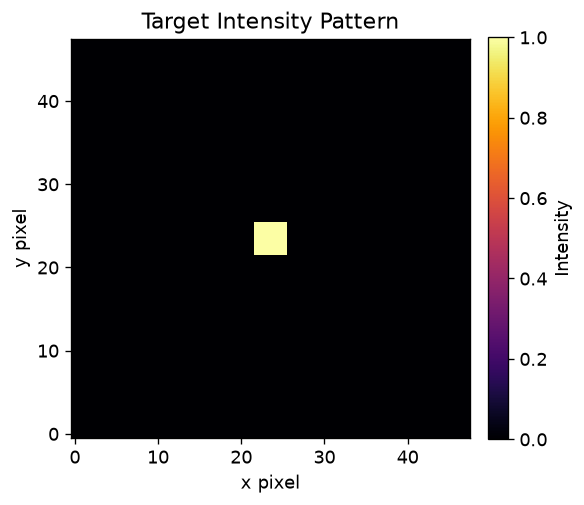

In [2]:
nx, ny = 48, 48
dx, dy = 4e-6, 4e-6
wavelength = 532e-9
z = 30e-3
n_steps = 50  # training iterations

# Target: bright centre spot
target = torch.zeros((ny, nx), dtype=torch.float32)
target[ny // 2 - 2 : ny // 2 + 2, nx // 2 - 2 : nx // 2 + 2] = 1.0

fig, ax = plt.subplots(figsize=(5, 5))
ax.imshow(target.numpy(), cmap="inferno", origin="lower")
ax.set_aspect("equal")
ax.set_box_aspect(1)
ax.set_title("Target Intensity Pattern")
ax.set_xlabel("x pixel")
ax.set_ylabel("y pixel")
plt.colorbar(ax.images[0], ax=ax, label="Intensity", fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

## 2. Train both cases

- **Case A (Weak)**: `bandlimit=False, pad=False` — vulnerable to aliasing
- **Case B (Validated)**: `bandlimit=True, pad=True` — numerically reliable

In [ ]:
from propagation_sanity.benchmarks.diff_optics import (
    optimize_diffractive_element,
    evaluate_phase_profile,
)

# Case A: Weak setup
print("Training Case A (Weak: no band-limit, no padding)...")
mod_a, losses_a = optimize_diffractive_element(
    target_intensity=target,
    nx=nx,
    ny=ny,
    dx=dx,
    dy=dy,
    wavelength=wavelength,
    z=z,
    bandlimit=False,
    pad=False,
    n_steps=n_steps,
    lr=0.2,
)
print(f"  Final training loss: {losses_a[-1]:.6f}")

# Case B: Validated setup
print("\nTraining Case B (Validated: band-limited + padded)...")
mod_b, losses_b = optimize_diffractive_element(
    target_intensity=target,
    nx=nx,
    ny=ny,
    dx=dx,
    dy=dy,
    wavelength=wavelength,
    z=z,
    bandlimit=True,
    pad=True,
    n_steps=n_steps,
    lr=0.2,
)
print(f"  Final training loss: {losses_b[-1]:.6f}")

Training Case A (Weak: no band-limit, no padding)...
  Final training loss: 0.006069

Training Case B (Validated: band-limited + padded)...
  Final training loss: 0.010656


## 3. Training loss curves

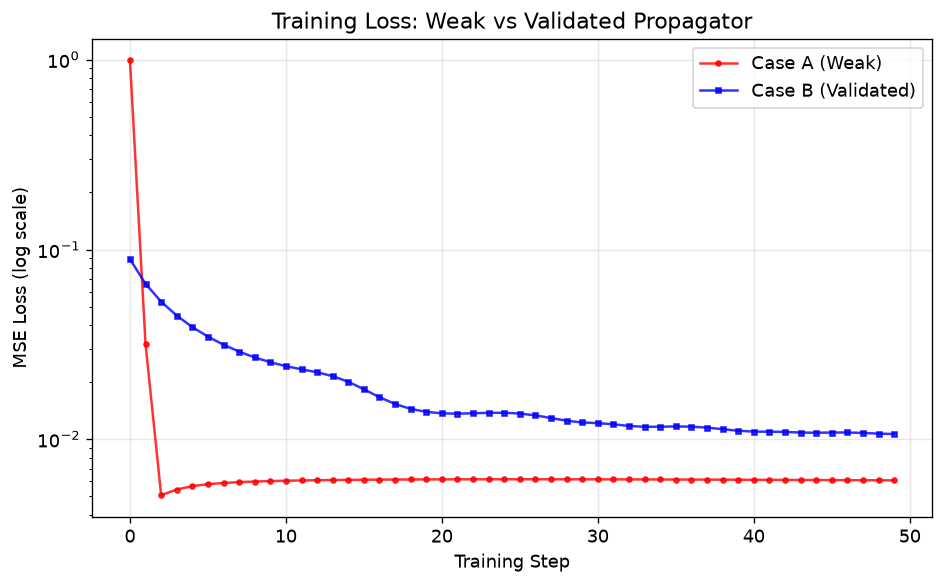

In [4]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.semilogy(losses_a, "r-o", ms=3, label="Case A (Weak)", alpha=0.8)
ax.semilogy(losses_b, "b-s", ms=3, label="Case B (Validated)", alpha=0.8)

ax.set_xlabel("Training Step")
ax.set_ylabel("MSE Loss (log scale)")
ax.set_title("Training Loss: Weak vs Validated Propagator")
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 4. Learned phase profiles

Compare the phase masks learned by the two optimisers.

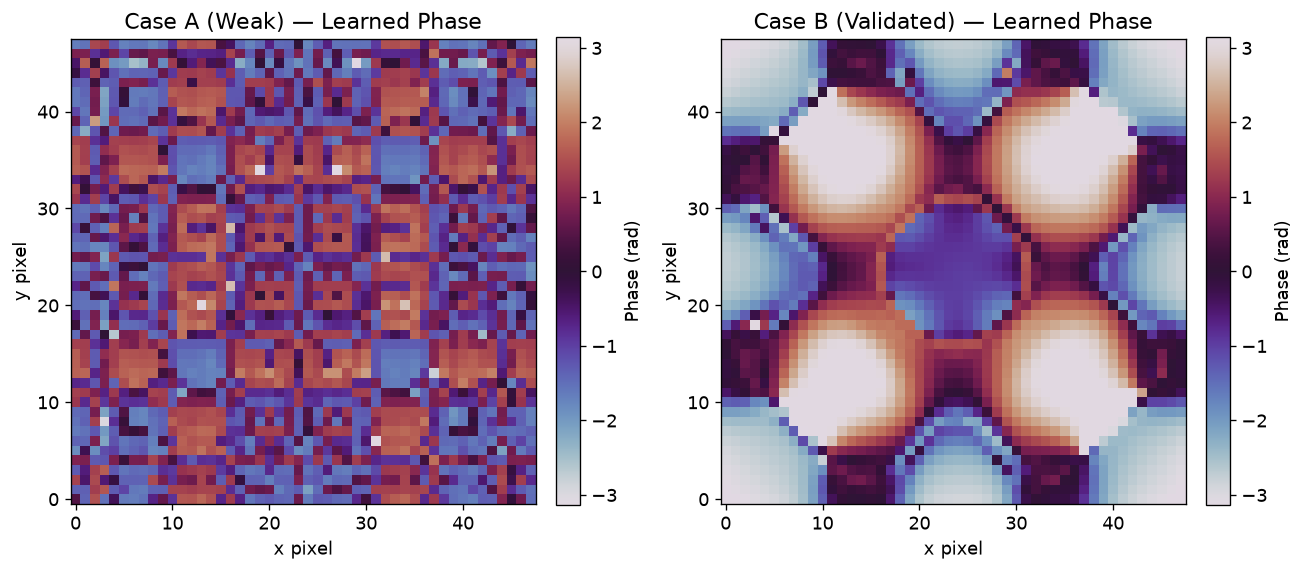

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(11, 5))

phase_a = mod_a.phase.detach().numpy()
phase_b = mod_b.phase.detach().numpy()

im0 = axes[0].imshow(phase_a, cmap="twilight", origin="lower", vmin=-np.pi, vmax=np.pi)
axes[0].set_aspect("equal")
axes[0].set_box_aspect(1)
axes[0].set_title("Case A (Weak) — Learned Phase")
plt.colorbar(im0, ax=axes[0], label="Phase (rad)", fraction=0.046, pad=0.04)

im1 = axes[1].imshow(phase_b, cmap="twilight", origin="lower", vmin=-np.pi, vmax=np.pi)
axes[1].set_aspect("equal")
axes[1].set_box_aspect(1)
axes[1].set_title("Case B (Validated) — Learned Phase")
plt.colorbar(im1, ax=axes[1], label="Phase (rad)", fraction=0.046, pad=0.04)

for ax in axes:
    ax.set_xlabel("x pixel")
    ax.set_ylabel("y pixel")

fig.tight_layout()
plt.show()

## 5. Cross-verification

The critical test: evaluate **both** learned phase profiles
under the **validated propagator** (BLAS + padding).

If Case A has overfit to aliasing artefacts, its loss under
the validated propagator will be dramatically worse.

In [ ]:
# Evaluate both under the validated propagator
eval_a = evaluate_phase_profile(
    mod_a,
    target,
    nx=nx,
    ny=ny,
    dx=dx,
    dy=dy,
    wavelength=wavelength,
    z=z,
    bandlimit=True,
    pad=True,
)
eval_b = evaluate_phase_profile(
    mod_b,
    target,
    nx=nx,
    ny=ny,
    dx=dx,
    dy=dy,
    wavelength=wavelength,
    z=z,
    bandlimit=True,
    pad=True,
)

print("Cross-Verification (evaluated under validated propagator):")
print("=" * 55)
print(f"  Case A (trained weak):      loss = {eval_a:.6f}")
print(f"  Case B (trained validated):  loss = {eval_b:.6f}")
print()

if eval_a > 2 * eval_b:
    print("⚠  Case A shows NUMERICAL OVERFITTING:")
    print("   Its low training loss was due to exploiting aliasing,")
    print("   not physically meaningful optimisation.")
else:
    print("Both cases perform comparably under cross-verification.")

Cross-Verification (evaluated under validated propagator):
  Case A (trained weak):      loss = 0.041447
  Case B (trained validated):  loss = 0.010662

⚠  Case A shows NUMERICAL OVERFITTING:
   Its low training loss was due to exploiting aliasing,
   not physically meaningful optimisation.


## 6. Output patterns: training propagator vs. validated propagator

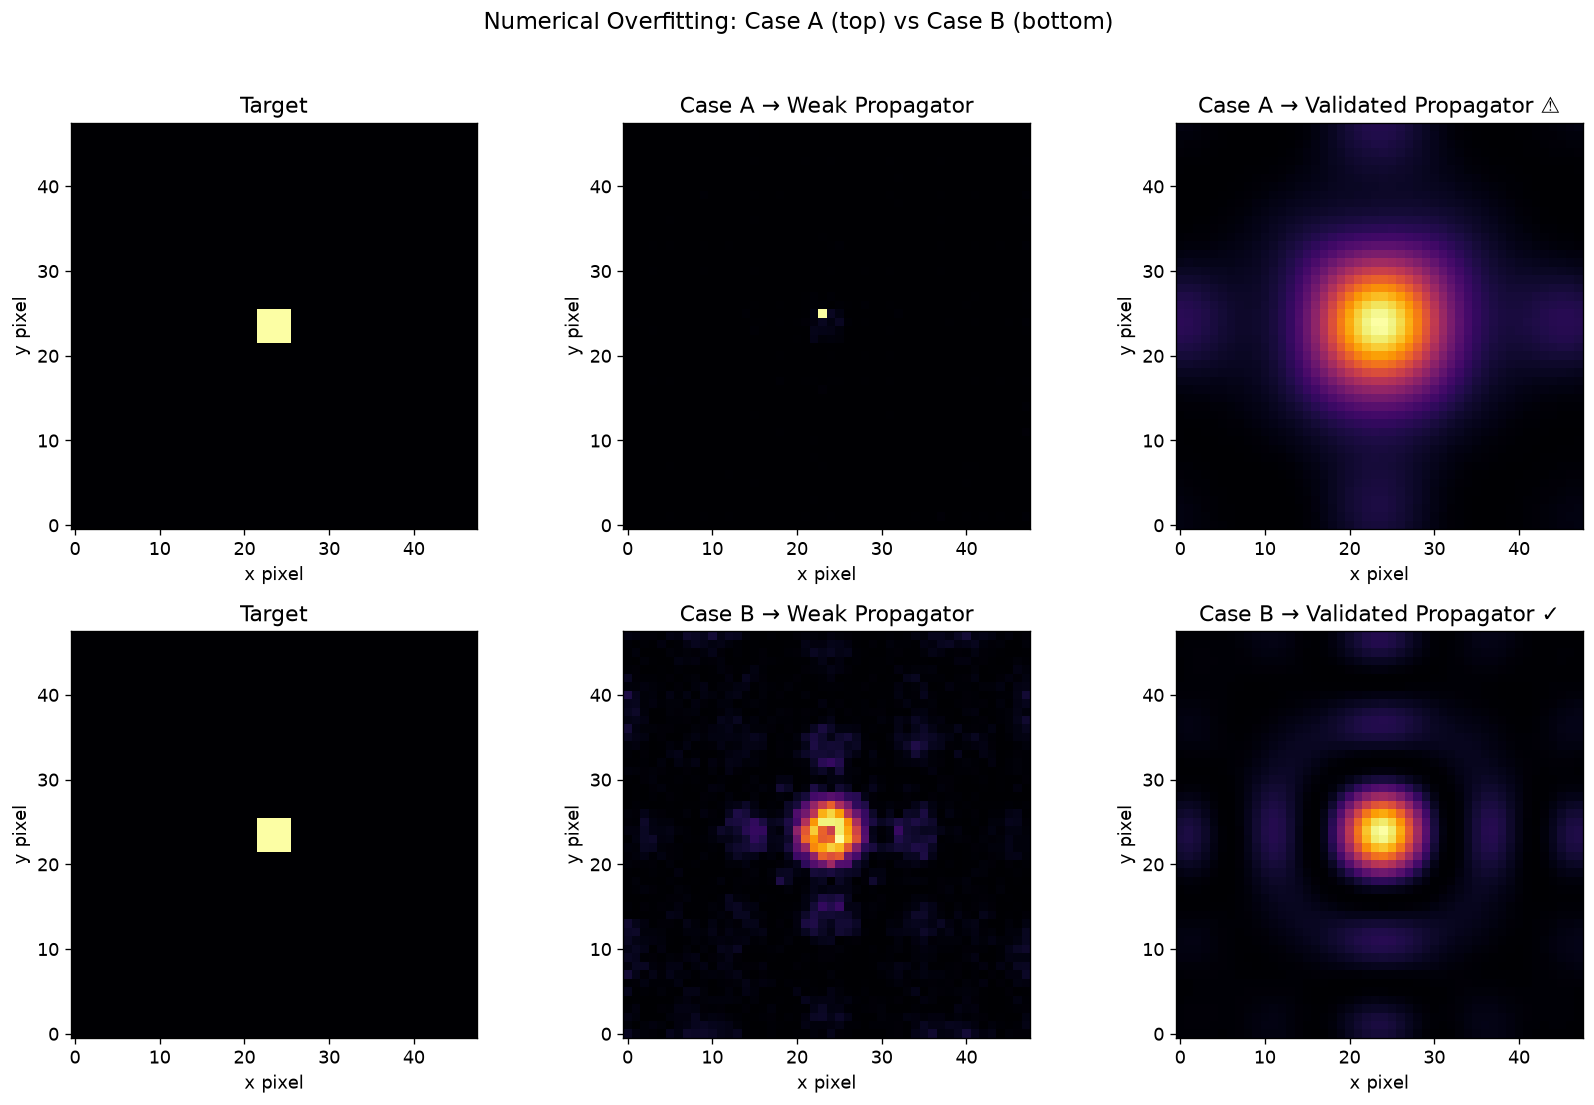

In [ ]:
from waveprop.rs import angular_spectrum


def forward_propagate(modulator, bandlimit, pad):
    """Forward propagation helper."""
    input_wave = torch.ones((ny, nx), dtype=torch.complex64)
    with torch.no_grad():
        modulated = modulator(input_wave)
        propagated, _, _ = angular_spectrum(
            u_in=modulated,
            wv=wavelength,
            d1=[dy, dx],
            dz=z,
            bandlimit=bandlimit,
            pad=pad,
            device="cpu",
        )
    intensity = torch.abs(propagated) ** 2
    return (intensity / (intensity.max() + 1e-12)).numpy()


fig, axes = plt.subplots(2, 3, figsize=(14, 9))

# Row 0: Case A
out_a_weak = forward_propagate(mod_a, bandlimit=False, pad=False)
out_a_valid = forward_propagate(mod_a, bandlimit=True, pad=True)

axes[0, 0].imshow(target.numpy(), cmap="inferno", origin="lower")
axes[0, 0].set_title("Target")
axes[0, 1].imshow(out_a_weak, cmap="inferno", origin="lower")
axes[0, 1].set_title("Case A → Weak Propagator")
axes[0, 2].imshow(out_a_valid, cmap="inferno", origin="lower")
axes[0, 2].set_title("Case A → Validated Propagator ⚠")

# Row 1: Case B
out_b_weak = forward_propagate(mod_b, bandlimit=False, pad=False)
out_b_valid = forward_propagate(mod_b, bandlimit=True, pad=True)

axes[1, 0].imshow(target.numpy(), cmap="inferno", origin="lower")
axes[1, 0].set_title("Target")
axes[1, 1].imshow(out_b_weak, cmap="inferno", origin="lower")
axes[1, 1].set_title("Case B → Weak Propagator")
axes[1, 2].imshow(out_b_valid, cmap="inferno", origin="lower")
axes[1, 2].set_title("Case B → Validated Propagator ✓")

for ax_row in axes:
    for ax in ax_row:
        ax.set_aspect("equal")
        ax.set_box_aspect(1)
        ax.set_xlabel("x pixel")
        ax.set_ylabel("y pixel")

fig.suptitle(
    "Numerical Overfitting: Case A (top) vs Case B (bottom)", fontsize=14, y=1.02
)
fig.tight_layout()
plt.show()

## 7. Summary table

In [ ]:
from propagation_sanity.benchmarks.diff_optics import (
    run_differentiable_optics_comparison,
)

results = run_differentiable_optics_comparison(n_steps=n_steps)

print(f"{'':30s}  {'Training Loss':>14s}  {'Cross-Verified':>14s}")
print("=" * 65)
print(
    f"{'Case A (Weak)':30s}"
    f"  {results['case_a_training_loss_final']:14.6f}"
    f"  {results['case_a_on_validated_propagator']:14.6f}"
)
print(
    f"{'Case B (Validated)':30s}"
    f"  {results['case_b_training_loss_final']:14.6f}"
    f"  {results['case_b_on_validated_propagator']:14.6f}"
)
print()
print("A large gap in 'Cross-Verified' loss indicates numerical overfitting.")

                                 Training Loss  Cross-Verified
Case A (Weak)                         0.006069        0.041447
Case B (Validated)                    0.010656        0.010662

A large gap in 'Cross-Verified' loss indicates numerical overfitting.


## Key takeaways

1. **Low training loss ≠ physically correct**: An optimizer can exploit
   aliased frequency channels in an unvalidated propagator to minimise
   loss, producing a design that fails under any other propagator.

2. **Band-limiting is critical for inverse design**: Using BLAS
   (Matsushima & Shimobaba, 2009) removes aliased channels and forces
   the optimizer to use only physically reliable modes.

3. **Always cross-verify**: The sanity check toolkit's core idea —
   run the same configuration under a validated propagator and compare.

4. **This applies beyond DOEs**: Any gradient-based optimization
   through FFT propagation (metalens design, holography, wavefront
   shaping) is susceptible to numerical overfitting.